# Project idea
Develop a system that takes a decent-sized CSV with class imbalance (~8-10k rows) and returns high-quality synthetic data to address that imbalance while preserving realistic data behavior.

## Core changes
- Move to a hosted LLM API service (not small local models).
- Use full-input/full-output flow: entire dataset context goes in, augmented dataset comes out.

## Example use case
User data input:
```
car_brand,car_type,year,car_price
Toyota,sedan,2004,2500
Nissan,hatchback,2010,4300
Honda,suv,2007,5000
```
User instructions:
```
Create 50 more examples of this car survey, from Blacktown, NSW, Australia. Minimize outliers while maintaining realism.
```
Expected patterns in output:
- Contains a diverse number of car brands found in NSW, Australia.
- Contains correct car types and brands (no hallucination of unrelated entities).
- Contains a distribution of years and prices centered around 2000s and early 2010s, with lower-end pricing.
- Shows reasonable relationships between price and year, and price and car type.

## Generation pipeline
1. Input full source CSV and augmentation instruction.
2. Ask the LLM API to infer dataset structure, constraints, and class-level patterns.
3. Generate additional rows for the underrepresented class(es).
4. Return a parseable augmented CSV with schema preserved.

## Evaluation setup (proposed)
1. Find a dataset with ~5-10k rows, preferably initially balanced.
Proposed dataset: `https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset`
2. Filter to around 7 columns to keep the task controlled.
3. Use stratified sampling to preserve overall distribution.
4. Remove ~30% of one class to simulate imbalance.
5. Run the imbalanced data through the augmentation model.

## Metrics
- Formatting: CSV parseability, schema adherence, and data type validity.
- Overall distribution shift: how much post-augmentation distributions differ from the original balanced baseline.
- Correlation fidelity: whether variable relationships are preserved, and how correlation matrices differ from the original dataset.
- Semantic accuracy: how well generated rows reflect inferred dataset characteristics and real-world plausibility.

# 0: Data and libraries

In [16]:
import numpy as np
import pandas as pd
import groq
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# 1: Transforming and cleaning data
Data used is from `https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset`, containing the rows of:

```
ID: ID of each client
LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)
SEX: Gender (1=male, 2=female)
EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
MARRIAGE: Marital status (1=married, 2=single, 3=others)
AGE: Age in years
PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
PAY_2: Repayment status in August, 2005 (scale same as above)
PAY_3: Repayment status in July, 2005 (scale same as above)
PAY_4: Repayment status in June, 2005 (scale same as above)
PAY_5: Repayment status in May, 2005 (scale same as above)
PAY_6: Repayment status in April, 2005 (scale same as above)
BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
default.payment.next.month: Default payment (1=yes, 0=no)
```
Final rows include:
```
LIMIT_BALL: number
SEX: 'male' or 'female'
EDUCATION: 'graduate', 'university', 'high school', 'others', drop unknown classes
MARRIAGE: 0, 1
AGE: number
PAYMENT_BALANCE_*: PAY_AMT* - BILL_AMT*
DEFAULT: 0, 1
```


In [12]:
# Build a cleaned version of the dataset based on the rules above.
working = df.copy()

# Standardize target column name.
working = working.rename(columns={"default.payment.next.month": "DEFAULT"})

# Keep only valid classes for EDUCATION and MARRIAGE.
working = working[working["EDUCATION"].isin([1, 2, 3, 4])]
working = working[working["MARRIAGE"].isin([1, 2])]

# Map coded values to readable categories.
working["SEX"] = working["SEX"].map({1: "male", 2: "female"})
working["EDUCATION"] = working["EDUCATION"].map({
    1: "graduate",
    2: "university",
    3: "high school",
    4: "others"
})

# Keep MARRIAGE as binary (married=1, single=0).
working["MARRIAGE"] = working["MARRIAGE"].map({1: 1, 2: 0})

# Create PAYMENT_BALANCE_i = PAY_AMTi - BILL_AMTi for i in 1..6.
for i in range(1, 7):
    working[f"PAYMENT_BALANCE_{i}"] = working[f"BILL_AMT{i}"] - working[f"PAY_AMT{i}"]

# Select final columns for modeling/augmentation.
final_columns = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAYMENT_BALANCE_1",
    "PAYMENT_BALANCE_2",
    "PAYMENT_BALANCE_3",
    "PAYMENT_BALANCE_4",
    "PAYMENT_BALANCE_5",
    "PAYMENT_BALANCE_6",
    "DEFAULT",
]

clean_df = working[final_columns].dropna().reset_index(drop=True)

clean_df.head()
clean_df.shape

clean_df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAYMENT_BALANCE_1,PAYMENT_BALANCE_2,PAYMENT_BALANCE_3,PAYMENT_BALANCE_4,PAYMENT_BALANCE_5,PAYMENT_BALANCE_6,DEFAULT
0,20000.0,female,university,1,24,3913.0,2413.0,689.0,0.0,0.0,0.0,1
1,120000.0,female,university,0,26,2682.0,725.0,1682.0,2272.0,3455.0,1261.0,1
2,90000.0,female,university,0,34,27721.0,12527.0,12559.0,13331.0,13948.0,10549.0,0
3,50000.0,female,university,1,37,44990.0,46214.0,48091.0,27214.0,27890.0,28547.0,0
4,50000.0,male,university,1,57,6617.0,-31011.0,25835.0,11940.0,18457.0,18452.0,0


# 2: Visualizing and analyzing trends

array([[<Axes: title={'center': 'LIMIT_BAL'}>,
        <Axes: title={'center': 'MARRIAGE'}>,
        <Axes: title={'center': 'AGE'}>],
       [<Axes: title={'center': 'PAYMENT_BALANCE_1'}>,
        <Axes: title={'center': 'PAYMENT_BALANCE_2'}>,
        <Axes: title={'center': 'PAYMENT_BALANCE_3'}>],
       [<Axes: title={'center': 'PAYMENT_BALANCE_4'}>,
        <Axes: title={'center': 'PAYMENT_BALANCE_5'}>,
        <Axes: title={'center': 'PAYMENT_BALANCE_6'}>],
       [<Axes: title={'center': 'DEFAULT'}>, <Axes: >, <Axes: >]],
      dtype=object)

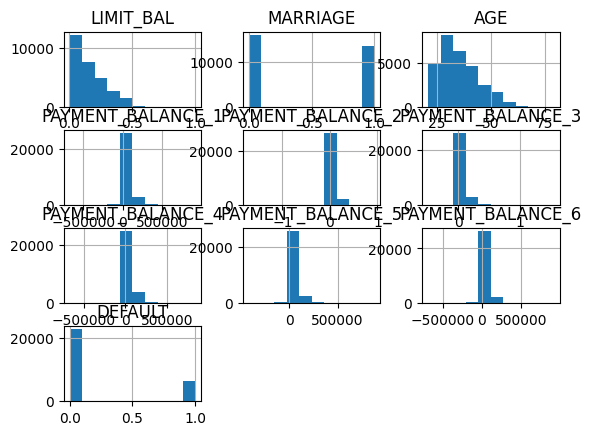

In [ ]:
import